In [4]:
BEST_PATH="./result/HSTU_Taobao/1776636551/best.pth"
checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval() 
with torch.no_grad():
    table = model.behavior_mod.current_pair_bias_table().detach().cpu().mean(dim=0)

labels = ['Pad', 'PV', 'Fav', 'Cart', 'Buy']
print("\n--- Effective Behavior Transition Bias (AFTER MASK) ---")
header = "Query\\Key | " + " | ".join([f"{l:^8}" for l in labels])
print(header)
print("-" * len(header))
for i, q_label in enumerate(labels):
    row_values = " | ".join([f"{val:^8.4f}" for val in table[i]])
    print(f"{q_label:^10} | {row_values}")


--- Effective Behavior Transition Bias (AFTER MASK) ---
Query\Key |   Pad    |    PV    |   Fav    |   Cart   |   Buy   
----------------------------------------------------------------
   Pad     |  0.0000  |  0.0000  |  0.0000  |  0.0000  |  0.0000 
    PV     |  0.0000  |  0.0669  |  0.0206  |  0.0252  |  0.0199 
   Fav     |  0.0000  |  0.2715  |  0.0302  | -0.0034  | -0.0089 
   Cart    |  0.0000  |  0.1724  |  0.7723  |  0.0355  | -0.0097 
   Buy     |  0.0000  |  0.1772  |  0.7794  |  1.1730  |  0.0926 


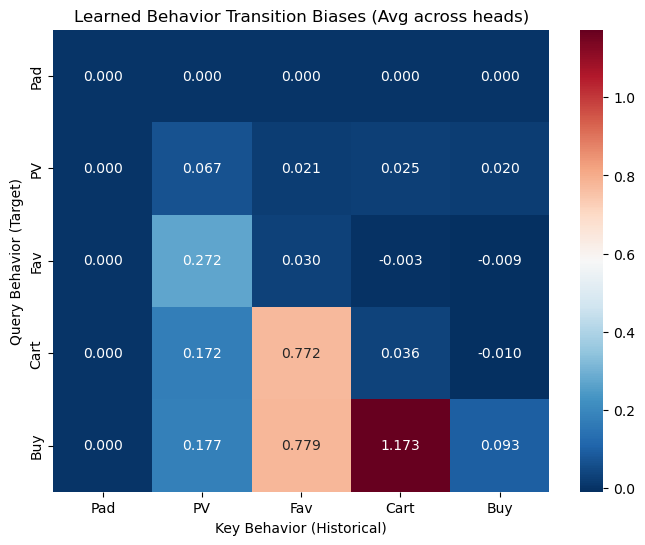

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_behavior_pair_bias(model, bias):
    # 提取学习到的偏置权重
    # shape: [n_heads, n_types, n_types]
    
    labels = ['Pad', 'PV', 'Fav', 'Cart', 'Buy']
    plt.figure(figsize=(8, 6))
    sns.heatmap(bias, annot=True, fmt=".3f", cmap='RdBu_r', 
                xticklabels=labels, yticklabels=labels)
    plt.title("Learned Behavior Transition Biases (Avg across heads)")
    plt.xlabel("Key Behavior (Historical)")
    plt.ylabel("Query Behavior (Target)")
    plt.show()

plot_behavior_pair_bias(model, table)

正在筛选 3 个具有代表性的高动态样本...
已找到第 1 个样本...
已找到第 2 个样本...
已找到第 3 个样本...
已找到第 4 个样本...
已找到第 5 个样本...
已找到第 6 个样本...
已找到第 7 个样本...


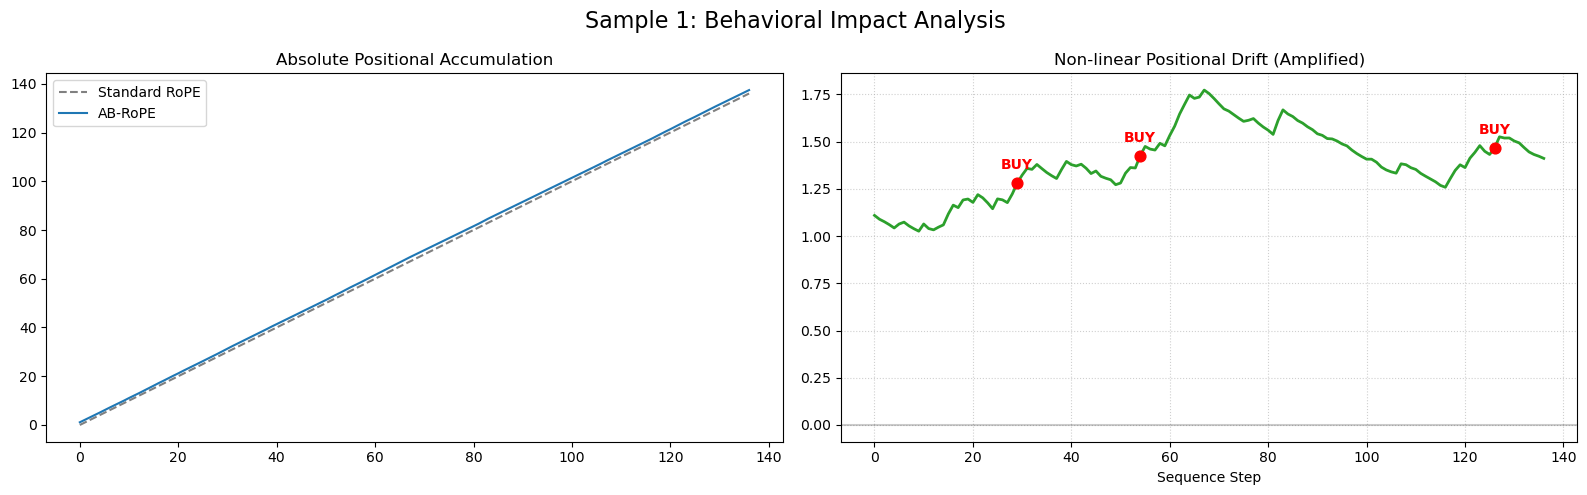

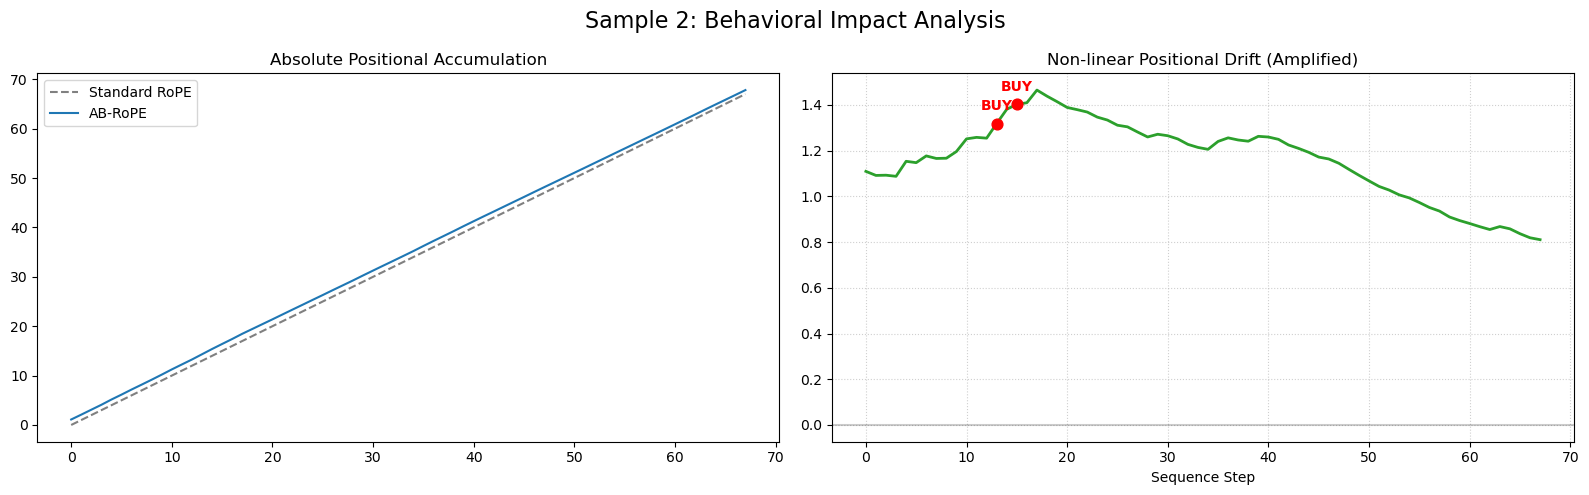

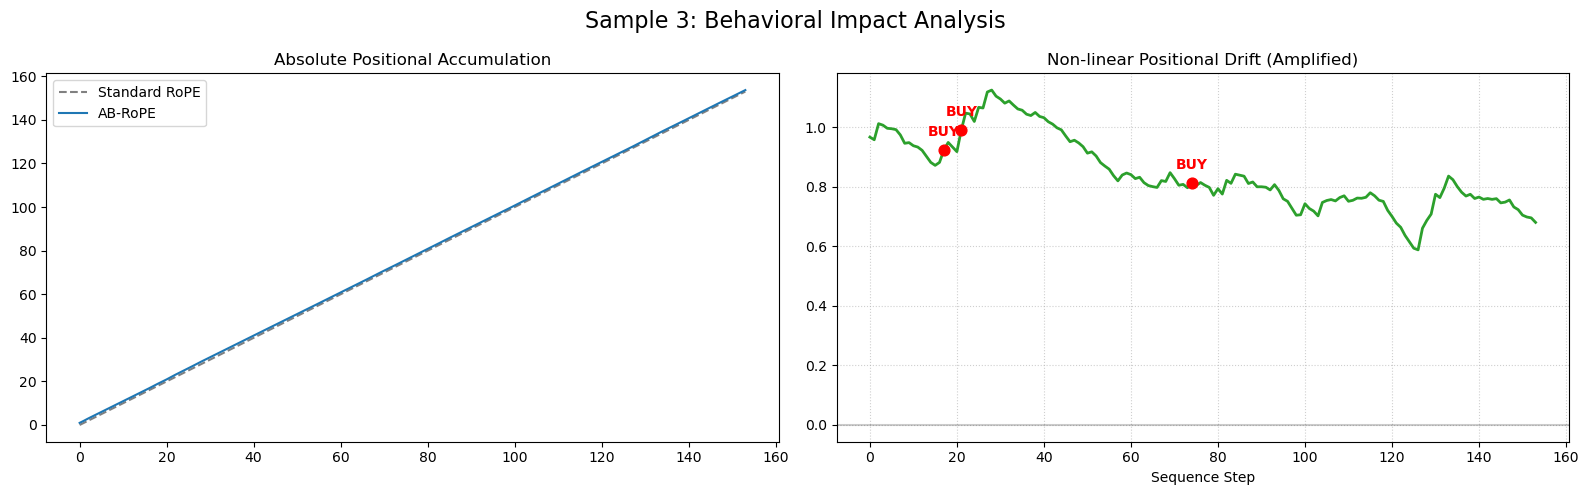

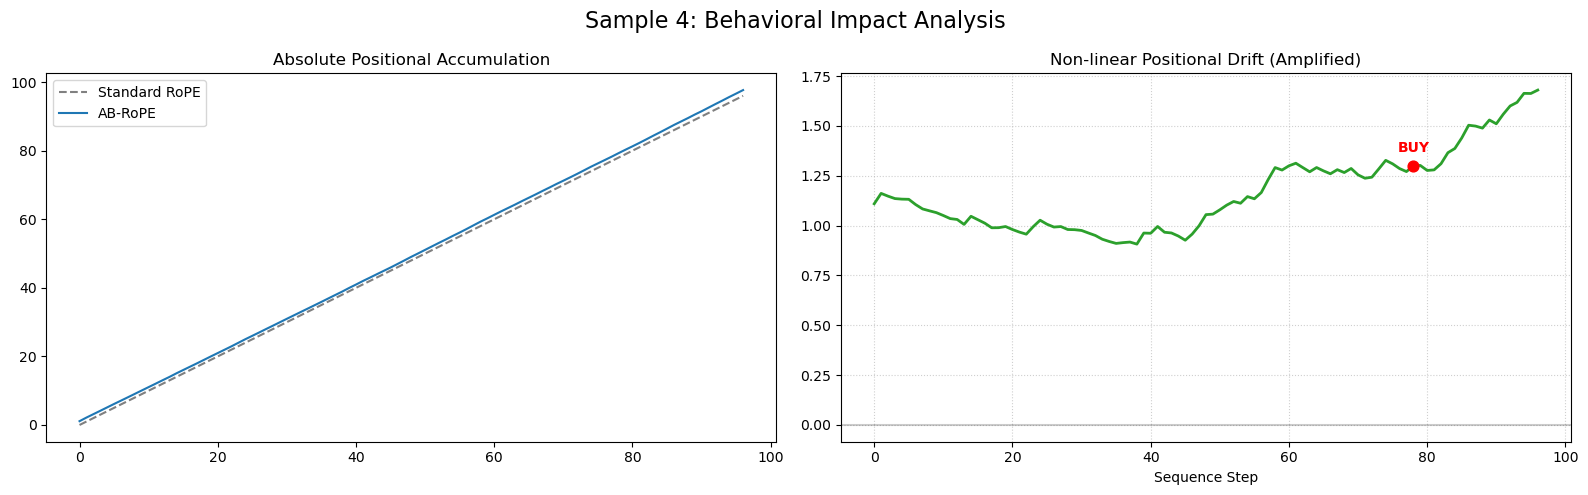

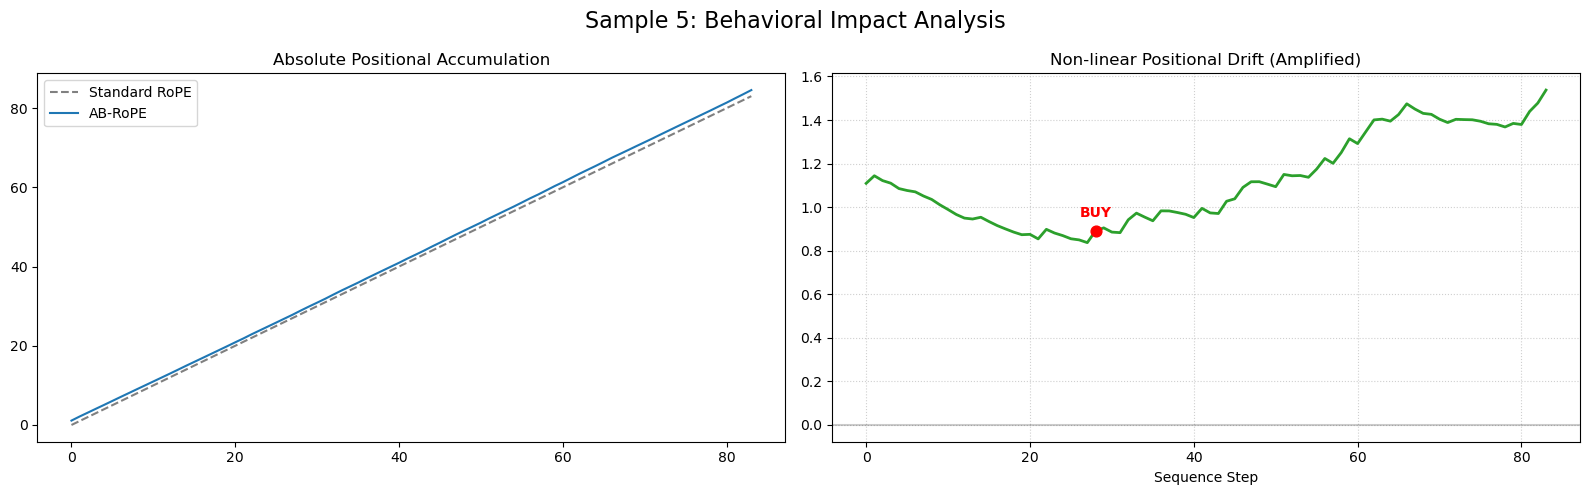

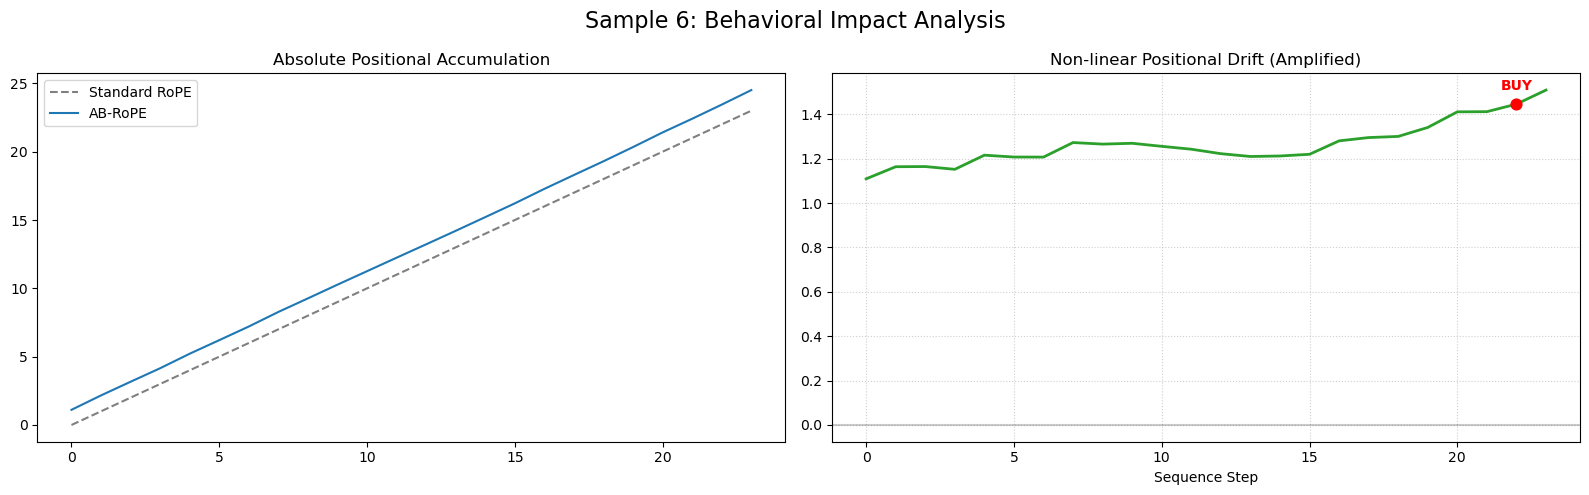

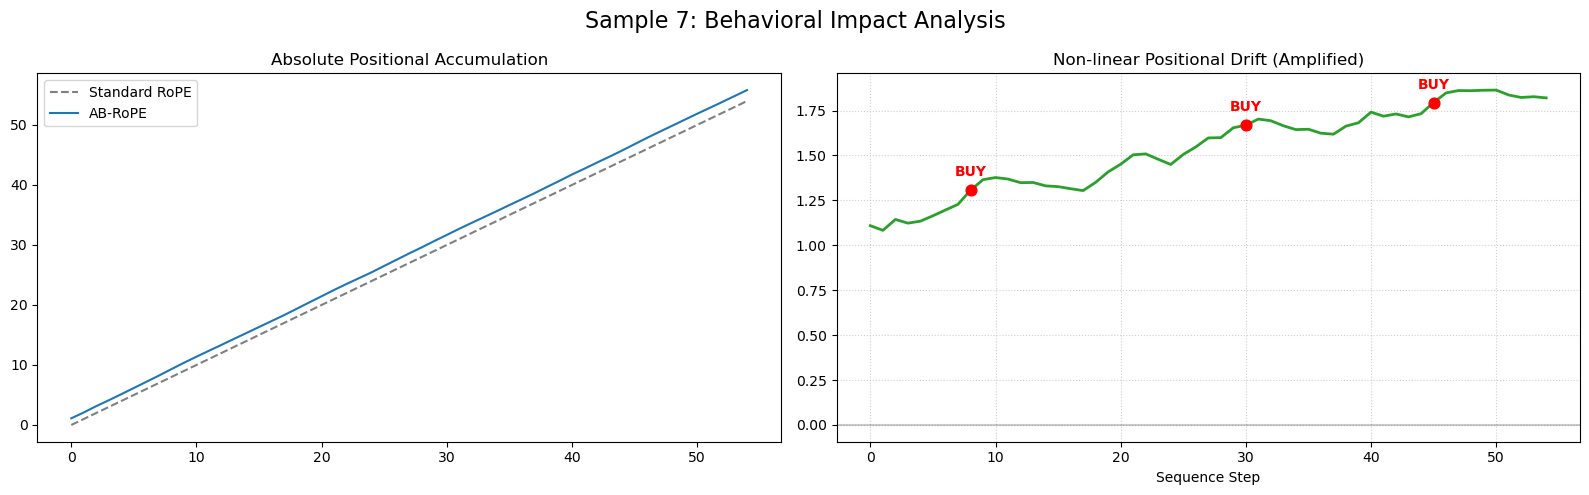

In [15]:
def plot_three_ab_rope_drifts(model, dataloader, device):
    model.eval()
    target_batches = []
    
    print("正在筛选 7 个具有代表性的高动态样本...")

    for batch in dataloader:
        types = batch["train_type_seq"][0].numpy()
        valid_mask = types != 0
        if (4 in types) and np.sum(valid_mask) > 20:
            target_batches.append(batch)
            print(f"已找到第 {len(target_batches)} 个样本...")
        
        if len(target_batches) >= 7:
            break

    if len(target_batches) < 7:
        print(f"样本不足，仅找到 {len(target_batches)} 个样本。")
    
    for idx, target_batch in enumerate(target_batches):
        type_seq = target_batch["train_type_seq"].to(device)
        seq_time = target_batch["train_time_seq"].to(device)
        
        with torch.no_grad():
            rope_lambda, _, _, _, _, _, _ = model.behavior_mod(type_seq, seq_time)
            
        logical_pos = torch.cumsum(rope_lambda.squeeze(-1), dim=1).cpu().numpy()[0]
        types = type_seq.cpu().numpy()[0]
        
        valid_idx = np.where(types != 0)[0]
        logical_pos = logical_pos[valid_idx]
        types = types[valid_idx]
        
        physical_pos = np.arange(len(logical_pos))
        drift = logical_pos - physical_pos 

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f"Sample {idx+1}: Behavioral Impact Analysis", fontsize=16)

        # 左图：绝对位置
        ax1.plot(physical_pos, physical_pos, '--', color='gray', label='Standard RoPE')
        ax1.plot(physical_pos, logical_pos, color='#1f77b4', label='AB-RoPE')
        ax1.set_title("Absolute Positional Accumulation")
        ax1.legend()

        # 右图：放大漂移图
        ax2.plot(physical_pos, drift, color='#2ca02c', linewidth=2, label='Positional Drift ($P_i - i$)')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.2)
        
        for i, t in enumerate(types):
            if t == 4: # Buy
                ax2.scatter(i, drift[i], color='red', s=60, zorder=5)
                ax2.annotate('BUY', (i, drift[i]), textcoords="offset points", xytext=(0,10), ha='center', color='red', weight='bold')
            # elif t == 3: # Cart
            #     ax2.scatter(i, drift[i], color='orange', s=40, zorder=5)
            #     ax2.annotate('Cart', (i, drift[i]), textcoords="offset points", xytext=(0,10), ha='center', color='orange')

        ax2.set_title("Non-linear Positional Drift (Amplified)")
        ax2.set_xlabel("Sequence Step")
        ax2.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

plot_three_ab_rope_drifts(model, test_dataloader, device)

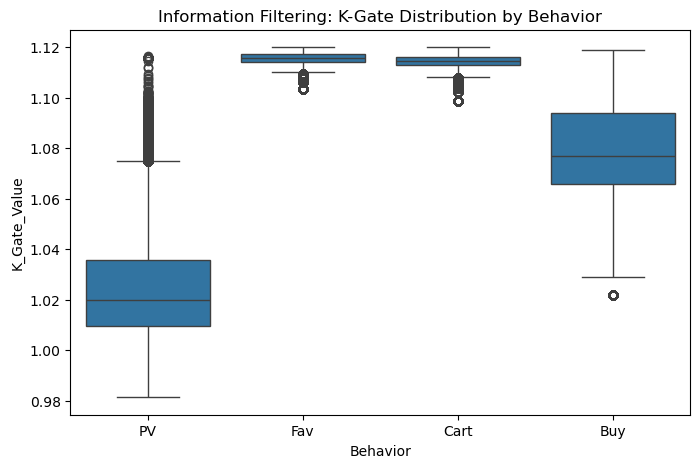

In [16]:
def plot_gating_analysis(model, dataloader, device, num_batches=50):
    all_data = []
    type_map = {1: 'PV', 2: 'Fav', 3: 'Cart', 4: 'Buy'}
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_batches: break
            type_seq = batch["train_type_seq"].to(device)
            seq_time = batch["train_time_seq"].to(device)
            
            # 获取门控信号
            _, q_g, k_g, v_g, _, _, _ = model.behavior_mod(type_seq, seq_time)
            
            for t_id, t_name in type_map.items():
                mask = (type_seq == t_id)
                if mask.any():
                    # 记录 K-Gate 的均值（控制历史信息的保留程度）
                    vals = k_g[mask].cpu().numpy().flatten()
                    for v in vals:
                        all_data.append({'Behavior': t_name, 'K_Gate_Value': v})

    df = pd.DataFrame(all_data)
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Behavior', y='K_Gate_Value', data=df)
    plt.title("Information Filtering: K-Gate Distribution by Behavior")
    plt.show()

plot_gating_analysis(model, test_dataloader, device)